## Setup

In [ ]:
# Cell 1: Install và import thư viện
%conda install fastai torch torchvision pycocotools scikit-learn cpuonly -q

In [ ]:
%pip install datatorch --quite

## Datatorch

In [ ]:
import datatorch as dt
from google.colab import userdata

api = dt.api.ApiClient(userdata.get('DATATORCH_API_KEY'))

# For the default schema named 'All'
api.project('gierusalem/bia4').download('All-Coco')

## Classification

In [1]:
from fastai.vision.all import *

### sample

In [ ]:
set_seed(42, reproducible=True)
path = untar_data(URLs.PETS)/'images'
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2,
    label_func=lambda x: x[0].isupper(), item_tfms=Resize(224))

In [ ]:
learn = vision_learner(dls, resnet18, pretrained=True, metrics=error_rate)
learn.fine_tune(3)

In [ ]:
img = PILImage.create(path/'Abyssinian_109.jpg')
print(f"Probability it's a cat: {learn.predict(img)[2][1].item():.6f}")

### Bia4 Dataset

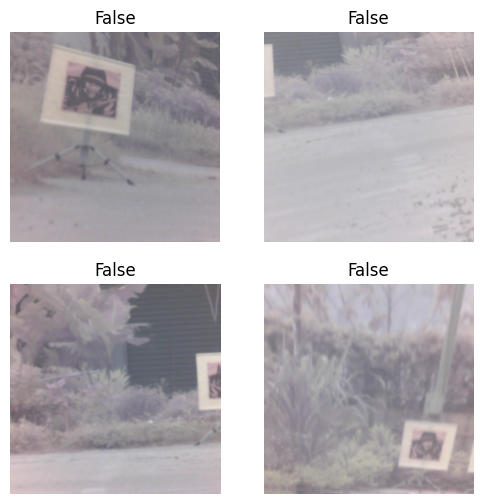

In [2]:
from fastai.vision.all import *
import json
import pandas as pd
from pathlib import Path
from shapely.geometry import Point, Polygon

# Load COCO JSON
with open('/content/All-Coco-3.json') as f:
    coco_data = json.load(f)

# Helper function to check if a point is inside a bbox
def point_in_bbox(point, bbox):
    x, y = point
    x_min, y_min, width, height = bbox
    return x_min <= x <= x_min + width and y_min <= y <= y_min + height

# Create DataFrame for labeling
data = []
for img in coco_data['images']:
    img_id = img['id']
    img_path = f"/content/{img['file_name']}"
    img_center = (img['width'] / 2, img['height'] / 2)  # Center point (x, y)
    label = False  # Default: not Bia4_Inside

    # Find annotations for this image with category_id = 3 (Bia4_Inside)
    for ann in coco_data['annotations']:
        if ann['image_id'] == img_id and ann['category_id'] == 3:
            # Check if center is inside bbox
            if point_in_bbox(img_center, ann['bbox']):
                label = True
                break

    data.append([img_path, label])

# Create DataFrame
df = pd.DataFrame(data, columns=['image_path', 'label'])

# Define FastAI DataBlock for binary classification
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('image_path'),
    get_y=ColReader('label'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms()
)

# Create DataLoader
dls = dblock.dataloaders(df, bs=32)

# Verify the data
dls.show_batch(max_n=4)

#### Centering Agument

In [8]:
import json
import numpy as np
from PIL import Image, ImageDraw
import os
import pandas as pd
from uuid import uuid4

# Load original COCO JSON
with open('/content/All-Coco-3.json') as f:
    coco_data = json.load(f)

# Function to create mask from segmentation
def create_mask(width, height, segmentation):
    mask = Image.new('L', (width, height), 0)
    draw = ImageDraw.Draw(mask)
    poly_points = [(segmentation[i], segmentation[i+1]) for i in range(0, len(segmentation), 2)]
    if len(poly_points) < 3:
        return np.zeros((height, width), dtype=np.uint8)
    draw.polygon(poly_points, fill=255)
    return np.array(mask)

# Directory for augmented images and JSON
aug_dir = '/content/augmented/'
os.makedirs(aug_dir, exist_ok=True)

# Lists for augmented data and new JSON
augmented_data = []
aug_json = {
    "info": coco_data['info'],
    "categories": coco_data['categories'],
    "images": [],
    "annotations": []
}

# Get max IDs for incrementing
max_img_id = max(img['id'] for img in coco_data['images'])
max_ann_id = max(ann['id'] for ann in coco_data['annotations'])

for img in coco_data['images']:
    img_id = img['id']
    img_path = f"/content/{img['file_name']}"
    img_center = (img['width'] / 2, img['height'] / 2)
    has_bia_inside = False
    ann_for_aug = None
    label = False
    for ann in coco_data['annotations']:
        if ann['image_id'] == img_id and ann['category_id'] == 3:
            has_bia_inside = True
            ann_for_aug = ann
            x_min, y_min, w, h = ann['bbox']
            if x_min <= img_center[0] <= x_min + w and y_min <= img_center[1] <= y_min + h:
                label = True
                break

    if has_bia_inside and not label and ann_for_aug:
        # Load image
        original_img = Image.open(img_path).convert('RGB')
        np_img = np.array(original_img)
        segmentation = ann_for_aug['segmentation'][0]

        # Create mask
        mask = create_mask(img['width'], img['height'], segmentation)
        if np.sum(mask) == 0:
            continue

        # Cut region using mask
        cut_region = np.zeros_like(np_img)
        for c in range(3):
            cut_region[:,:,c] = np_img[:,:,c] * (mask // 255)

        # Clear original region
        for c in range(3):
            np_img[:,:,c][mask > 0] = np.mean(np_img[:,:,c])

        # New position: center the segment
        seg_h, seg_w = int(h), int(w)
        new_x = max(0, min(int(img_center[0] - seg_w / 2), img['width'] - seg_w))
        new_y = max(0, min(int(img_center[1] - seg_h / 2), img['height'] - seg_h))

        # Paste cut region
        paste_mask = np.roll(np.roll(mask, new_y - int(y_min), axis=0), new_x - int(x_min), axis=1)
        for c in range(3):
            shifted_cut = np.roll(np.roll(cut_region[:,:,c], new_y - int(y_min), axis=0), new_x - int(x_min), axis=1)
            np_img[:,:,c][paste_mask > 0] = shifted_cut[paste_mask > 0]

        # Save augmented image
        aug_filename = f"aug_{img['file_name']}"
        aug_path = os.path.join(aug_dir, aug_filename)
        Image.fromarray(np_img).save(aug_path)

        # Add to augmented data
        augmented_data.append([aug_path, True])

        # Create new image entry
        max_img_id += 1
        new_img = {
            "id": max_img_id,
            "datatorch_id": str(uuid4()),
            "storage_id": str(uuid4()),
            "path": aug_filename,
            "width": img['width'],
            "height": img['height'],
            "file_name": aug_filename,
            "metadata": {},
            "date_captured": img['date_captured']
        }
        aug_json['images'].append(new_img)

        # Create new annotation entry
        max_ann_id += 1
        new_seg = [x + (new_x - x_min) for x in segmentation[::2]] + [y + (new_y - y_min) for y in segmentation[1::2]]
        new_seg = [new_seg[i % len(new_seg)] for i in range(len(new_seg))]
        new_ann = {
            "id": max_ann_id,
            "datatorch_id": str(uuid4()),
            "image_id": max_img_id,
            "category_id": 3,
            "segmentation": [new_seg],
            "area": ann_for_aug['area'],
            "bbox": [new_x, new_y, w, h],
            "iscrowd": 0,
            "metadata": {}
        }
        aug_json['annotations'].append(new_ann)

# Save augmented JSON
aug_json_path = os.path.join(aug_dir, 'augmented_coco.json')
with open(aug_json_path, 'w') as f:
    json.dump(aug_json, f, indent=2)

# Merge with original JSON
merged_coco = coco_data.copy()
merged_coco['images'].extend(aug_json['images'])
merged_coco['annotations'].extend(aug_json['annotations'])

# Save merged JSON
with open('/content/All-Coco-3-merged.json', 'w') as f:
    json.dump(merged_coco, f, indent=2)

# Create DataFrame for FastAI
aug_df = pd.DataFrame(augmented_data, columns=['image_path', 'label'])
print(f"Created {len(augmented_data)} augmented images and JSONs.")

Created 97 augmented images and JSONs.


### Show Dataset

Images: 197
Annotations: 390
Bia4_Inside annotations: 197
Categories: {1: 'Bia4_Outside', 2: 'ChanBia', 3: 'Bia4_Inside'}

All image files found.

Label distribution:
label
True     99
False    98
Name: count, dtype: int64


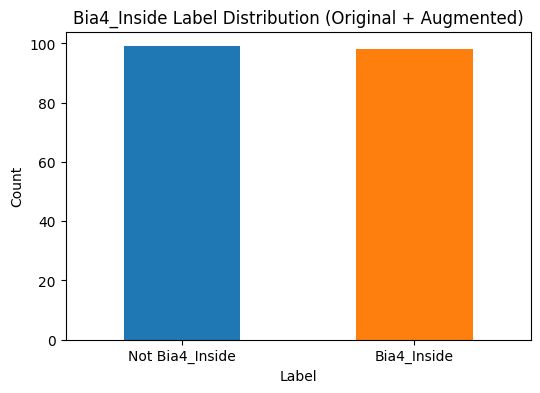


Image size stats:
Width range: 640 - 640
Height range: 480 - 480


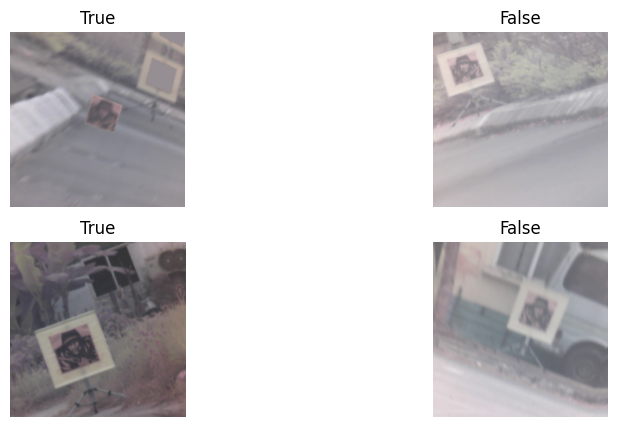

In [11]:
from fastai.vision.all import *
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load original COCO JSON
with open('/content/All-Coco-3.json') as f:
    coco_data = json.load(f)

# Load augmented JSON if it exists
aug_json_path = '/content/augmented/augmented_coco.json'
aug_coco_data = {"images": [], "annotations": []}
if Path(aug_json_path).exists():
    with open(aug_json_path) as f:
        aug_coco_data = json.load(f)

# Combine datasets
combined_images = coco_data['images'] + aug_coco_data['images']
combined_annotations = coco_data['annotations'] + aug_coco_data['annotations']
categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

# 1. Dataset Statistics
num_images = len(combined_images)
num_annotations = len(combined_annotations)
bia4_inside_count = sum(1 for ann in combined_annotations if ann['category_id'] == 3)

print(f"Images: {num_images}")
print(f"Annotations: {num_annotations}")
print(f"Bia4_Inside annotations: {bia4_inside_count}")
print("Categories:", categories)

# 2. Label DataFrame with file existence check
data = []
missing_files = []
for img in combined_images:
    img_id = img['id']
    # Set path based on whether it's an augmented image
    img_path = f"/content/augmented/{img['file_name']}" if img['file_name'].startswith('aug_') else f"/content/{img['file_name']}"
    # Check if file exists
    if not Path(img_path).exists():
        missing_files.append(img_path)
        continue
    img_center = (img['width'] / 2, img['height'] / 2)
    label = False
    for ann in combined_annotations:
        if ann['image_id'] == img_id and ann['category_id'] == 3:
            x_min, y_min, width, height = ann['bbox']
            if x_min <= img_center[0] <= x_min + width and y_min <= img_center[1] <= y_min + height:
                label = True
                break
    data.append([img_path, label])

# Report missing files
if missing_files:
    print(f"\nWarning: {len(missing_files)} files not found:")
    for f in missing_files[:5]:  # Show up to 5 for brevity
        print(f"  {f}")
else:
    print("\nAll image files found.")

# Create DataFrame
df = pd.DataFrame(data, columns=['image_path', 'label'])

# 3. Label Distribution
label_counts = df['label'].value_counts()
print("\nLabel distribution:")
print(label_counts)

# Plot label distribution
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Bia4_Inside Label Distribution (Original + Augmented)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Bia4_Inside', 'Bia4_Inside'], rotation=0)
plt.show()

# 4. Image Size Analysis
image_sizes = [(img['width'], img['height']) for img in combined_images if Path(f"/content/augmented/{img['file_name']}" if img['file_name'].startswith('aug_') else f"/content/{img['file_name']}").exists()]
widths, heights = zip(*image_sizes)
print(f"\nImage size stats:")
print(f"Width range: {min(widths)} - {max(widths)}")
print(f"Height range: {min(heights)} - {max(heights)}")

# 5. Visualize Sample Images with FastAI
batch_tfms = aug_transforms(mult=1.5, max_rotate=15, max_zoom=1.1, max_warp=0.1)
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('image_path'),
    get_y=ColReader('label'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=batch_tfms
)
dls = dblock.dataloaders(df, bs=32)
dls.show_batch(max_n=4, figsize=(10, 5))

### Tunning

TODO:
Hyperparameter Tuning:

Use learn.lr_find() for optimal learning rate.
Apply discriminative learning rates (lower for base, higher for head) with fit_one_cycle.
Tune batch size (e.g., 32-128) and weight decay (1e-4 to 1e-2).
Employ Bayesian optimization for params like epochs, dropout.

Model Architecture:

Switch to resnet50 or resnet101 for deeper features.
Try vision transformers via timm (e.g., vit_base_patch16_224).
Use efficientnet_b0 or higher for efficiency.
Ensemble multiple models (e.g., resnet + vit).

In [12]:
# Create learner with pre-trained ResNet34
learn = vision_learner(dls, resnet50, pretrained=true, metrics=accuracy)

#### First round

In [13]:
# Fine-tune the model
learn.fine_tune(epochs=4, base_lr=1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.185236,0.493838,0.743590,00:02


epoch,train_loss,valid_loss,accuracy,time
0,0.456232,0.378567,0.846154,00:02
1,0.546216,0.322472,0.846154,00:02
2,0.483645,0.321320,0.897436,00:02
3,0.417875,0.290501,0.948718,00:02


[0.802463710308075, 0.6500000357627869]


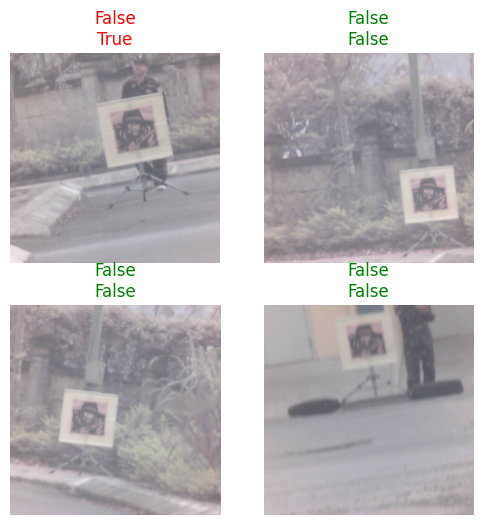

In [5]:
# Evaluate results
learn.show_results(max_n=4)
print(learn.validate())

#### Second round

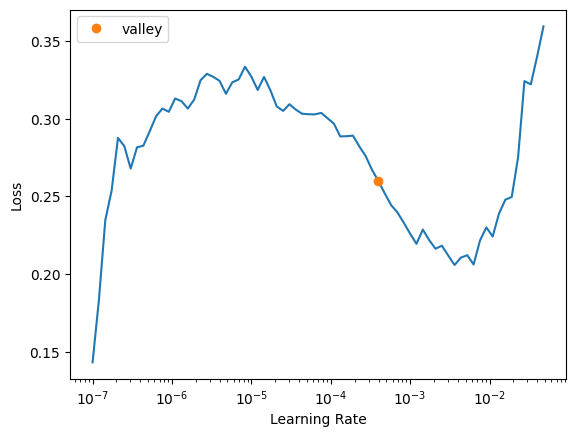

In [14]:
lr_min = learn.lr_find()
plt.show()

In [15]:
# Choose lr with steepest loss drop, e.g., 1e-4
learn.fine_tune(8, base_lr=lr_min.valley)

epoch,train_loss,valid_loss,accuracy,time
0,0.339356,0.295953,0.897436,00:02


epoch,train_loss,valid_loss,accuracy,time
0,0.374804,0.253468,0.897436,00:02
1,0.303006,0.217288,0.923077,00:02
2,0.281852,0.142781,0.948718,00:02
3,0.326311,0.163142,0.948718,00:02
4,0.312946,0.196300,0.897436,00:02
5,0.288340,0.238745,0.897436,00:02
6,0.272118,0.283193,0.897436,00:02
7,0.262881,0.298183,0.897436,00:02


## Influent

In [21]:
# 1. Make Predictions on a Single Image
img_path = '/content/bia4 (887).bmp'  # Example image
pred, pred_idx, probs = learn.predict(img_path)
print(f"Prediction: {pred}, Probability: {probs[pred_idx]:.4f}")

Prediction: True, Probability: 0.9225


In [18]:
# 2. Evaluate on Validation Set
val_loss, val_accuracy = learn.validate()
print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")

# 3. Visualize Predictions
learn.show_results(max_n=4, figsize=(10, 5))  # Show 4 validation set predictions

# 4. Get Predictions on a Batch
test_dl = learn.dls.test_dl(df['image_path'][:10])  # Example: first 10 images
preds, _ = learn.get_preds(dl=test_dl)
pred_labels = [learn.dls.vocab[pred.argmax()] for pred in preds]
print("Batch Predictions:", pred_labels)

# 6. Interpret Results (Confusion Matrix)
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

Prediction: False, Probability: 0.9223


/usr/local/lib/python3.12/dist-packages/fastprogress/fastprogress.py:73: UserWarning: Your generator is empty.
  warn("Your generator is empty.")


TypeError: unsupported format string passed to NoneType.__format__

In [17]:
# 5. Export/Load Model
learn.export('bia4_inside_model.pkl')  # Save model
learn = load_learner('bia4_inside_model.pkl')  # Load model later

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")
